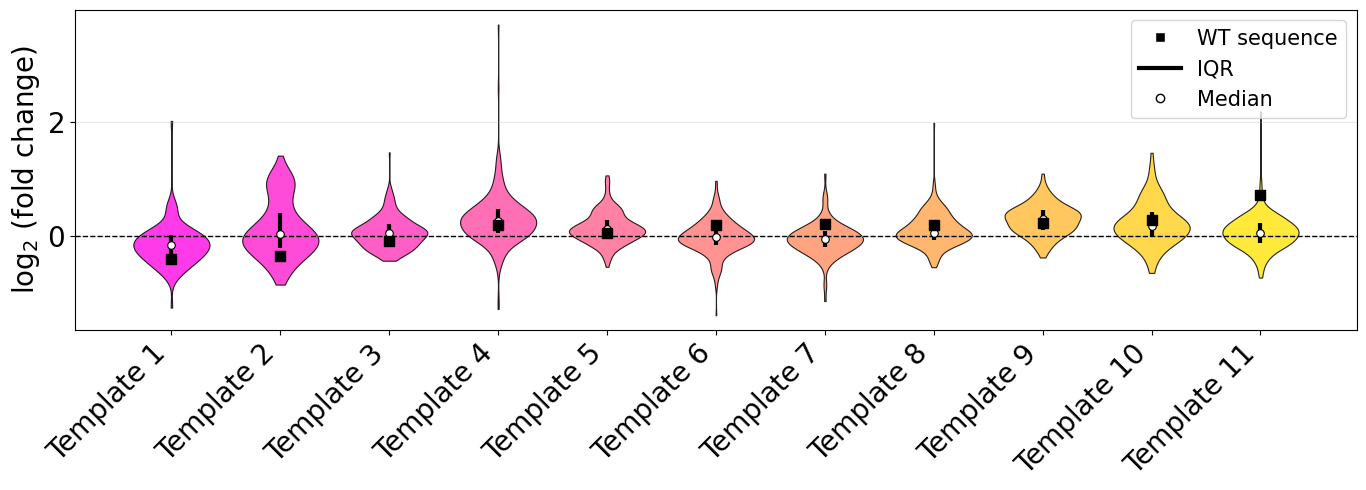

In [ ]:
## Violin plot of log2FC distributions per template (with template values)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# ── Weighted meta-analysis (same as volcano script) ──────────────────────────
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep')
                   and c[-1] in ['1', '2', '3']])
se_cols  = sorted([c for c in df1.columns if c.startswith('lfcSE_rep')
                   and c[-1] in ['1', '2', '3']])

lfc_data = df1[lfc_cols].values
se_data  = df1[se_cols].values
weights  = 1 / (se_data ** 2)

df1['weighted_log2FC'] = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)

# ── Colormap (same truncated spring) ─────────────────────────────────────────
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))

truncated_spring = truncate_colormap(plt.cm.spring, 0.10, 0.90)

row_order = [
    'syn_LEA_1',
    'At2g46140_tile7',
    'TgL_8x',
    'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4',
    'A0A438HAK2',
    'Asyn_isoform_5',
    'A0A1U8F7A1',
    'Os_LEA_or6',
    'Os_LEA_or4',
    'A0A4D6M434',
]

colors = {
    origin: truncated_spring(i / (len(row_order) - 1))
    for i, origin in enumerate(row_order)
}

# ── Collect data & WT values ──────────────────────────────────────────────────
plot_data = []
wt_values = []

for origin in row_order:
    variants = df1[df1['base_origin'] == origin]['weighted_log2FC'].dropna().values
    plot_data.append(variants)

    wt_id  = f'original_sequence_-_{origin}'
    wt_row = df1[df1['Sequence_ID'] == wt_id]
    wt_values.append(wt_row['weighted_log2FC'].values[0] if len(wt_row) else np.nan)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

positions = np.arange(len(row_order))

for i, (origin, data, wt) in enumerate(zip(row_order, plot_data, wt_values)):
    color = colors[origin]

    vp = ax.violinplot(data, positions=[i], widths=0.7,
                       showmedians=False, showextrema=False)

    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_edgecolor('black')
        body.set_linewidth(0.8)
        body.set_alpha(0.85)

    # IQR box
    q25, med, q75 = np.percentile(data, [25, 50, 75])
    ax.vlines(i, q25, q75, color='black', linewidth=3, zorder=4)   # IQR bar
    ax.scatter(i, med, color='white', edgecolors='black',
               s=30, zorder=5, linewidths=0.8)                     # median dot

    # WT as black square
    if not np.isnan(wt):
        ax.scatter(i, wt, marker='s', color='black', s=50, zorder=6)

ax.axhline(0, color='k', linestyle='--', linewidth=1)

ax.set_xticks(positions)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xticklabels([f'Template {i+1}' for i in range(len(row_order))], rotation=45, ha='right', fontsize=20)
ax.set_ylabel('log$_2$ (fold change)', fontsize=20)
ax.grid(axis='y', alpha=0.3)

# Legend
wt_patch  = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='black',
                        markersize=7, label='WT sequence')
iqr_patch = plt.Line2D([0], [0], color='black', linewidth=3, label='IQR')
med_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                        markeredgecolor='black', markersize=6, label='Median')
ax.legend(handles=[wt_patch, iqr_patch, med_patch], fontsize=15,
          loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('violin_log2fc_per_template.svg', format='svg', bbox_inches='tight', dpi=300)
#plt.savefig('violin_log2fc_per_template.png', format='png', bbox_inches='tight', dpi=300)
plt.show()


LFC columns: ['log2FoldChange_rep1', 'log2FoldChange_rep2', 'log2FoldChange_rep3']
SE columns: ['lfcSE_rep1', 'lfcSE_rep2', 'lfcSE_rep3']


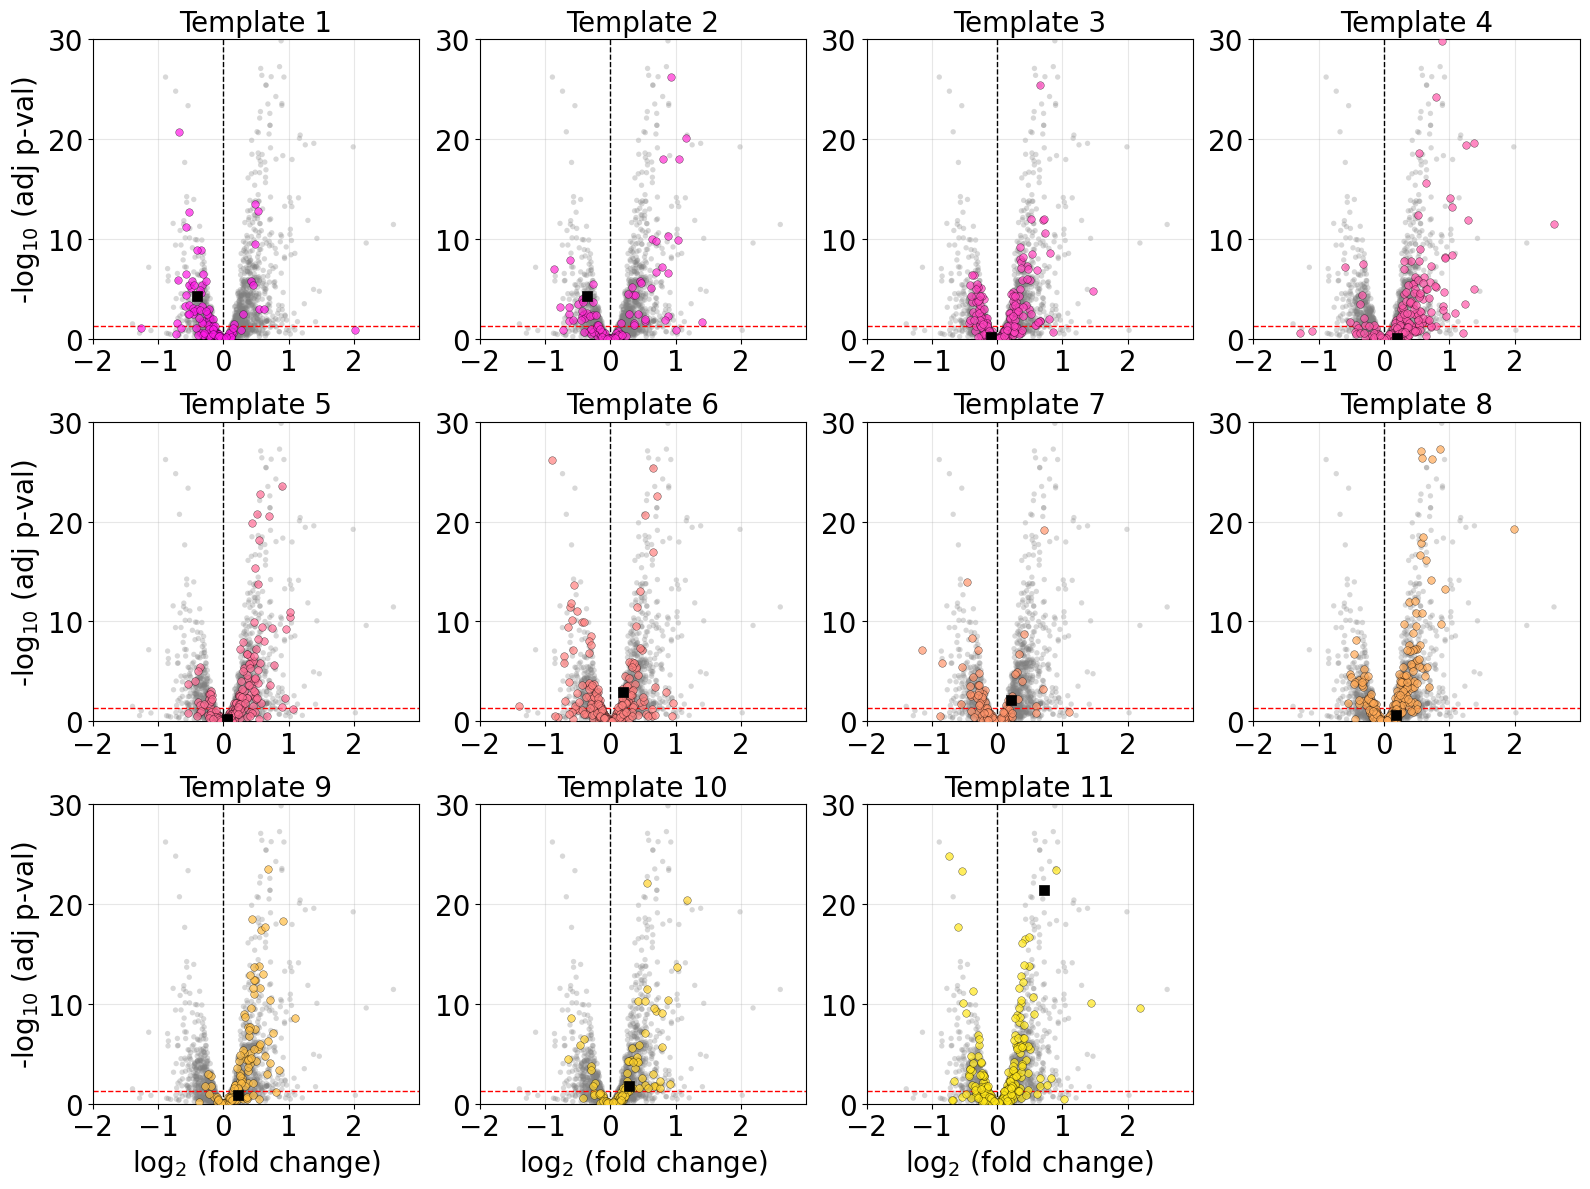

In [ ]:
## Volcano plots for each group with template highlighted, using weighted log2FC and adjusted p-values, colored by template

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# Identify columns for reps 1-3
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep') 
                   and c[-1] in ['1', '2', '3']])
se_cols = sorted([c for c in df1.columns if c.startswith('lfcSE_rep') 
                  and c[-1] in ['1', '2', '3']])

print(f"LFC columns: {lfc_cols}")
print(f"SE columns: {se_cols}")

# Extract data
lfc_data = df1[lfc_cols].values
se_data = df1[se_cols].values

# Calculate inverse-variance weights
weights = 1 / (se_data ** 2)

# Weighted mean LFC
df1['weighted_log2FC'] = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)

# Pooled SE of weighted mean
df1['pooled_SE'] = 1 / np.sqrt(np.nansum(weights, axis=1))

# Calculate z-score (testing if log2FC != 0)
df1['z_score'] = df1['weighted_log2FC'] / df1['pooled_SE']

# Calculate two-tailed p-value
df1['pvalue'] = 2 * stats.norm.sf(np.abs(df1['z_score']))

# Adjust p-values for multiple testing
_, df1['padj'], _, _ = multipletests(df1['pvalue'], method='fdr_bh')

# Calculate -log10(padj)
df1['neg_log10_padj'] = -np.log10(df1['padj'].replace(0, 1e-300))

# Templates 1-11
row_order = [
    'syn_LEA_1',
    'At2g46140_tile7',
    'TgL_8x',
    'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4',
    'A0A438HAK2',
    'Asyn_isoform_5',
    'A0A1U8F7A1',
    'Os_LEA_or6',
    'Os_LEA_or4',
    'A0A4D6M434',
]

# Create truncated spring colormap (remove tail ends)
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

spring_cmap = plt.cm.spring
truncated_spring = truncate_colormap(spring_cmap, 0.10, 0.90)

# Assign colors evenly across truncated colormap
colors = {origin: truncated_spring(i / (len(row_order) - 1)) for i, origin in enumerate(row_order)}

# Create multi-panel figure (3 rows x 4 columns for 11 plots)
n_rows, n_cols = 3, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for idx, origin in enumerate(row_order):
    ax = axes[idx]
    
    # Get variants in this group
    variants = df1[df1['base_origin'] == origin].copy()
    
    # Get the corresponding WT sequence
    wt_id = f'original_sequence_-_{origin}'
    wt = df1[df1['Sequence_ID'] == wt_id].copy()
    
    if len(wt) == 0:
        print(f"WT not found for {origin}, skipping...")
        continue
    
    # Get WT values
    wt_log2fc = wt['weighted_log2FC'].values[0]
    wt_neg_log10_padj = wt['neg_log10_padj'].values[0]
    
    # Get background points (everything NOT in this origin)
    background = df1[df1['base_origin'] != origin].copy()
    
    # Plot background points in gray first
    ax.scatter(background['weighted_log2FC'], background['neg_log10_padj'], 
               alpha=0.3, s=15, c='gray', edgecolors='none', zorder=1)
    
    # Plot all variants for this origin
    ax.scatter(variants['weighted_log2FC'], variants['neg_log10_padj'], 
               alpha=0.7, s=30, c=[colors[origin]], edgecolors='k', 
               linewidths=0.3, zorder=5)
    
    # Plot WT as black square
    ax.scatter(wt_log2fc, wt_neg_log10_padj, alpha=1.0, s=60, c='black', 
               edgecolors='k', linewidths=0.5, marker='s', zorder=10)
    
    ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    
    ax.set_xlim(-2, 3)
    ax.set_ylim(0, 30)
    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.grid(True, alpha=0.3)
    
    # Add panel label with template numbering
    ax.set_title(f'Template {idx+1}', fontsize=20)
    
    # Only add axis labels to edge panels
    if idx >= (n_rows - 1) * n_cols or idx == len(row_order) - 1:
        ax.set_xlabel('log$_2$ (fold change)', fontsize=20)
    if idx % n_cols == 0:
        ax.set_ylabel(r'-log$_{10}$ (adj p-val)', fontsize=20)

# Hide the empty subplot (12th panel)
axes[-1].axis('off')

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('volcano_plots_supplementary.svg', format='svg', bbox_inches='tight', dpi=300)
#plt.savefig('volcano_plots_supplementary.png', format='png', bbox_inches='tight', dpi=300)
plt.show()